In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/Global_Supply_Chain_2024to2025.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [89]:
print("Target distribution:")
print(df["Disruption_Occurred"].value_counts())

print("\nTarget distribution in percent:")
print(
    df["Disruption_Occurred"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDataset columns:")
print(df.columns.tolist())

Target distribution:
Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

Target distribution in percent:
Disruption_Occurred
1    61.26
0    38.74
Name: proportion, dtype: float64

Dataset columns:
['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']


In [90]:

target = "Disruption_Occurred"


features = [
    "Date",
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
]


X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nExcluded columns: Shipment_ID, Lead_Time_Days")

Feature matrix shape: (5000, 11)
Target vector shape: (5000,)

Features:
['Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score']

Excluded columns: Shipment_ID, Lead_Time_Days


In [91]:
# Extract calendar features from Date
X["Date_Month"] = X["Date"].dt.month
X["Date_DayOfWeek"] = X["Date"].dt.dayofweek

# Remove the original datetime column
X = X.drop(columns=["Date"])

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str", "category"]).columns.tolist()

print("Updated feature matrix shape:", X.shape)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Updated feature matrix shape: (5000, 12)

Numeric features:
['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Date_Month', 'Date_DayOfWeek']

Categorical features:
['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']


In [92]:
# Zeitbasierter Train-/Test-Split
# 2024 = Entwicklung
# 2025 = zeitlicher Test

data = X.copy()
data["Disruption_Occurred"] = y
data["Year"] = df["Date"].dt.year

# Trainingsdaten: 2024
train_data = data[data["Year"] == 2024].copy()

# Testdaten: 2025
test_data = data[data["Year"] == 2025].copy()

# Year wird nicht als Modellvariable benötigt
train_data = train_data.drop(columns=["Year"])
test_data = test_data.drop(columns=["Year"])

# Features und Target trennen
X_train = train_data.drop(columns=["Disruption_Occurred"])
y_train = train_data["Disruption_Occurred"]

X_test = test_data.drop(columns=["Disruption_Occurred"])
y_test = test_data["Disruption_Occurred"]

print("Training: 2024")
print("Training feature set:", X_train.shape)

print("\nTest: 2025")
print("Test feature set:", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training: 2024
Training feature set: (2455, 12)

Test: 2025
Test feature set: (2545, 12)

Training target distribution:
Disruption_Occurred
1    61.96
0    38.04
Name: proportion, dtype: float64

Test target distribution:
Disruption_Occurred
1    60.59
0    39.41
Name: proportion, dtype: float64


## Regelbasierte Risikoanalyse

Eine Lieferung wird als potenziell risikoreich eingestuft, wenn:

- der geopolitische Risikowert mindestens 6,67 beträgt oder
- die Wetterbedingung „Hurricane“ oder „Storm“ ist.

### Teststrategie

Die Regel wurde auf Basis der vorherigen Risikoanalyse definiert und anschließend mit Lieferungen aus dem Jahr 2025 getestet.

Damit wird die Regel auf einen zeitlich späteren Datensatz angewendet.

### Ergebnisse

Die Kennzahlen werden nach der Ausführung der Testdaten aktualisiert.

### Einschränkung

Die Regel basiert auf Mustern im vorhandenen Datensatz. Die Ergebnisse
zeigen die Performance für das Testjahr 2025 und sind keine Garantie
für zukünftige Lieferungen.

In [93]:
baseline_class = y_train.mode()[0]

baseline_predictions = pd.Series(
    baseline_class, 
    index=y_test.index
)

baseline_accuracy = (baseline_predictions == y_test).mean()

print("Baseline predicted class:", baseline_class)
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Baseline predicted class: 1
Baseline accuracy: 60.59%


In [94]:
geo_threshold = 6.67

rule_predictions = (
    (X_test["Geopolitical_Risk_Score"] >= geo_threshold)
    | (X_test["Weather_Condition"].isin(["Hurricane", "Storm"]))
).astype(int)

print("Regel:")
print(f"Geopolitisches Risiko >= {geo_threshold}")
print("ODER Wetter = Sturm / Hurrikan")

print("\nAnzahl potenziell riskanter Lieferungen:")
print(rule_predictions.sum())

print("\nAnteil potenziell riskanter Lieferungen:")
print(f"{rule_predictions.mean():.2%}")

Regel:
Geopolitisches Risiko >= 6.67
ODER Wetter = Sturm / Hurrikan

Anzahl potenziell riskanter Lieferungen:
1563

Anteil potenziell riskanter Lieferungen:
61.41%


In [95]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rule_predictions
})

confusion_matrix = pd.crosstab(
    comparison["Actual"],
    comparison["Predicted"],
    rownames=["Actual"],
    colnames=["Predicted"],
    margins=True
)

print("Confusion matrix:")
print(confusion_matrix)

Confusion matrix:
Predicted    0     1   All
Actual                    
0          658   345  1003
1          324  1218  1542
All        982  1563  2545


In [96]:
tn = confusion_matrix.loc[0, 0]
fp = confusion_matrix.loc[0, 1]
fn = confusion_matrix.loc[1, 0]
tp = confusion_matrix.loc[1, 1]

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1_score:.2%}")


Accuracy:  73.71%
Precision: 77.93%
Recall:    78.99%
F1-score:  78.45%


In [97]:
baseline_tp = ((baseline_predictions == 1) & (y_test == 1)).sum()
baseline_tn = ((baseline_predictions == 0) & (y_test == 0)).sum()
baseline_fp = ((baseline_predictions == 1) & (y_test == 0)).sum()
baseline_fn = ((baseline_predictions == 0) & (y_test == 1)).sum()

baseline_precision = baseline_tp / (baseline_tp + baseline_fp)
baseline_recall = baseline_tp / (baseline_tp + baseline_fn)


baseline_f1 = (
    2 * baseline_precision * baseline_recall
    / (baseline_precision + baseline_recall)
)


results = pd.DataFrame({
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Rule-Based": [
        accuracy,
        precision,
        recall,
        f1_score
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

results = results * 100

print("Performance comparison (%):")
display(results.round(2))


Performance comparison (%):


,Baseline,Rule-Based
Accuracy,60.59,73.71
Precision,60.59,77.93
Recall,100.00,78.99
F1-score,75.46,78.45


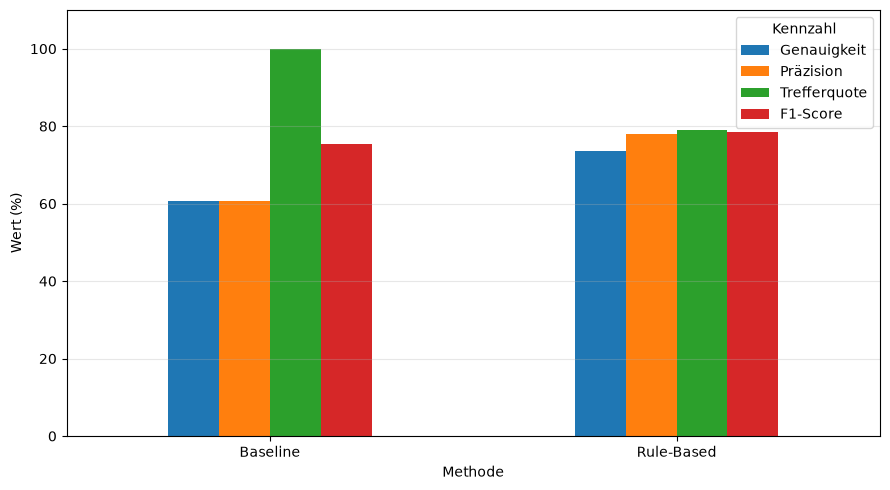

In [98]:
results_de = results.rename(
    index={
        "Accuracy": "Genauigkeit",
        "Precision": "Präzision",
        "Recall": "Trefferquote",
        "F1-score": "F1-Score"
    }
)

results_de.T.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 110),
    rot=0
)

plt.title("")
plt.ylabel("Wert (%)")
plt.xlabel("Methode")
plt.legend(title="Kennzahl")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

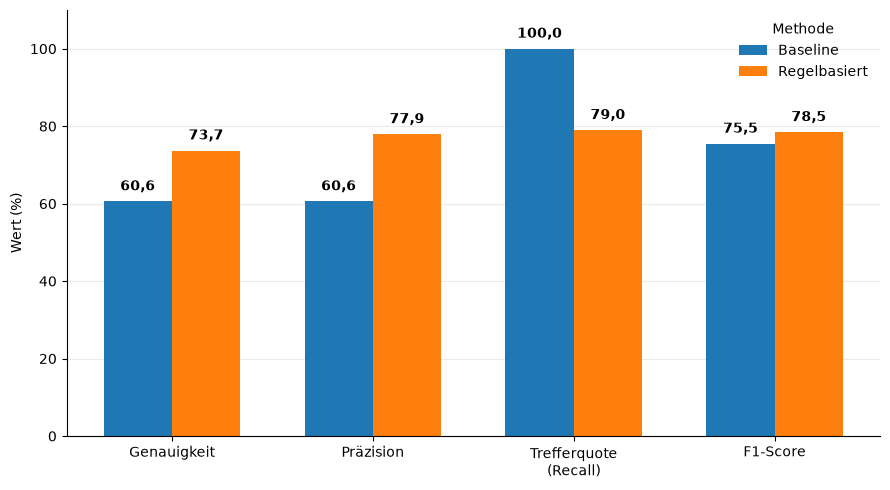

In [99]:
# Performance-Vergleich für die Präsentation



metrics = [
    "Genauigkeit",
    "Präzision",
    "Trefferquote\n(Recall)",
    "F1-Score"
]

baseline_values = [
    results.loc["Accuracy", "Baseline"],
    results.loc["Precision", "Baseline"],
    results.loc["Recall", "Baseline"],
    results.loc["F1-score", "Baseline"]
]

rule_values = [
    results.loc["Accuracy", "Rule-Based"],
    results.loc["Precision", "Rule-Based"],
    results.loc["Recall", "Rule-Based"],
    results.loc["F1-score", "Rule-Based"]
]

x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5))

bars_baseline = ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

bars_rule = ax.bar(
    x + width / 2,
    rule_values,
    width,
    label="Regelbasiert"
)

# Werte über den Balken
for bars in [bars_baseline, bars_rule]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 2,
            f"{value:.1f}".replace(".", ","),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Wert (%)")
ax.set_ylim(0, 110)

# Kein Titel – der Titel steht bereits auf der Canva-Folie
ax.set_title("")

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Methode",
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.show()

## Logistic Regression

Neben der regelbasierten Analyse wird eine Logistic Regression als statistisches Modell verwendet.

Das Modell untersucht, wie mehrere Einflussfaktoren gemeinsam mit der Wahrscheinlichkeit einer Lieferunterbrechung zusammenhängen.

Das Modell wird mit Lieferungen aus dem Jahr 2024 entwickelt und anschließend mit den Lieferungen aus dem Jahr 2025 getestet.

In [100]:
# Vorbereitung der Daten für die Logistic Regression

import statsmodels.api as sm

# Selected numerical variables
numeric_logit = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score"
]

# Select variables from the original training and test data
X_train_logit = X_train[numeric_logit].copy()
X_test_logit = X_test[numeric_logit].copy()

# Extreme weather indicator
# 1 = Storm or Hurricane
# 0 = other weather conditions
X_train_logit["Extreme_Weather"] = (
    X_train["Weather_Condition"].isin(["Storm", "Hurricane"])
).astype(int)

X_test_logit["Extreme_Weather"] = (
    X_test["Weather_Condition"].isin(["Storm", "Hurricane"])
).astype(int)

# Transport mode as dummy variables
train_transport = pd.get_dummies(
    X_train["Transport_Mode"],
    prefix="Transport_Mode",
    drop_first=True
)

test_transport = pd.get_dummies(
    X_test["Transport_Mode"],
    prefix="Transport_Mode",
    drop_first=True
)

# Make sure training and test have the same columns
test_transport = test_transport.reindex(
    columns=train_transport.columns,
    fill_value=0
)

# Add transport mode variables
X_train_logit = pd.concat(
    [X_train_logit, train_transport],
    axis=1
)

X_test_logit = pd.concat(
    [X_test_logit, test_transport],
    axis=1
)

# Convert everything to numeric
X_train_logit = X_train_logit.astype(float)
X_test_logit = X_test_logit.astype(float)

print("Trainingsdaten:", X_train_logit.shape)
print("Testdaten:", X_test_logit.shape)

print("\nVerwendete Merkmale:")
print(X_train_logit.columns.tolist())

Trainingsdaten: (2455, 9)
Testdaten: (2545, 9)

Verwendete Merkmale:
['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Extreme_Weather', 'Transport_Mode_Rail', 'Transport_Mode_Road', 'Transport_Mode_Sea']


In [101]:
# Logistic Regression trainieren

# Konstante für den Intercept hinzufügen
X_train_logit_const = sm.add_constant(X_train_logit)
X_test_logit_const = sm.add_constant(X_test_logit)

# Logistic Regression mit den Trainingsdaten aus 2024
logit_model = sm.Logit(
    y_train,
    X_train_logit_const
)

logit_result = logit_model.fit(
    disp=False,
    maxiter=200
)

print("Logistic Regression wurde erfolgreich trainiert.")
print(f"Anzahl Beobachtungen: {int(logit_result.nobs)}")
print(f"Anzahl Merkmale: {len(logit_result.params) - 1}")

Logistic Regression wurde erfolgreich trainiert.
Anzahl Beobachtungen: 2455
Anzahl Merkmale: 9


In [102]:
# Vorhersagen für das Testjahr 2025

# Wahrscheinlichkeit einer Lieferunterbrechung berechnen
logit_probabilities = logit_result.predict(X_test_logit_const)

# Wahrscheinlichkeit in 0/1-Klassifikation umwandeln
logit_predictions = (
    logit_probabilities >= 0.50
).astype(int)

print("Vorhersagen für 2025 wurden erstellt.")

print("\nErste 10 Wahrscheinlichkeiten:")
print(logit_probabilities.head(10))

print("\nAnzahl vorhergesagter Unterbrechungen:")
print(logit_predictions.sum())

print("\nAnteil vorhergesagter Unterbrechungen:")
print(f"{logit_predictions.mean():.2%}")

Vorhersagen für 2025 wurden erstellt.

Erste 10 Wahrscheinlichkeiten:
0     0.898884
8     0.406453
9     0.861326
11    0.321432
12    0.736172
18    0.248136
19    0.558149
21    0.958757
23    0.946444
24    0.234601
dtype: float64

Anzahl vorhergesagter Unterbrechungen:
1597

Anteil vorhergesagter Unterbrechungen:
62.75%


In [103]:
# Performance der Logistic Regression auf dem Testjahr 2025

# Confusion Matrix berechnen
cm_logit = pd.crosstab(
    y_test,
    logit_predictions,
    rownames=["Actual"],
    colnames=["Predicted"]
)

# Fehlende Zeilen/Spalten ergänzen, falls notwendig
cm_logit = cm_logit.reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

# Werte aus der Confusion Matrix
tn = cm_logit.loc[0, 0]
fp = cm_logit.loc[0, 1]
fn = cm_logit.loc[1, 0]
tp = cm_logit.loc[1, 1]

# Kennzahlen berechnen
accuracy_logit = (tp + tn) / (tp + tn + fp + fn)

precision_logit = tp / (tp + fp)

recall_logit = tp / (tp + fn)

f1_logit = (
    2 * precision_logit * recall_logit
    / (precision_logit + recall_logit)
)

print("Logistic Regression – Testjahr 2025")
print("------------------------------------")
print(f"Accuracy:  {accuracy_logit:.2%}")
print(f"Precision: {precision_logit:.2%}")
print(f"Recall:    {recall_logit:.2%}")
print(f"F1-score:  {f1_logit:.2%}")

print("\nConfusion Matrix:")
print(cm_logit)

Logistic Regression – Testjahr 2025
------------------------------------
Accuracy:  74.58%
Precision: 78.02%
Recall:    80.80%
F1-score:  79.39%

Confusion Matrix:
Predicted    0     1
Actual              
0          652   351
1          296  1246


In [104]:
# Vergleich der Modelle

comparison = pd.DataFrame({
    "Accuracy": [
        results.loc["Accuracy", "Baseline"],
        results.loc["Accuracy", "Rule-Based"],
        accuracy_logit * 100
    ],
    "Precision": [
        results.loc["Precision", "Baseline"],
        results.loc["Precision", "Rule-Based"],
        precision_logit * 100
    ],
    "Recall": [
        results.loc["Recall", "Baseline"],
        results.loc["Recall", "Rule-Based"],
        recall_logit * 100
    ],
    "F1-score": [
        results.loc["F1-score", "Baseline"],
        results.loc["F1-score", "Rule-Based"],
        f1_logit * 100
    ]
}, index=[
    "Baseline",
    "Regelbasiert",
    "Logistic Regression"
])

comparison.round(2)

,Accuracy,Precision,Recall,F1-score
Baseline,60.59,60.59,100.00,75.46
Regelbasiert,73.71,77.93,78.99,78.45
Logistic Regression,74.58,78.02,80.80,79.39


In [105]:
# Koeffizienten der Logistic Regression


logit_coefficients = pd.DataFrame({
    "Variable": logit_result.params.index,
    "Coefficient": logit_result.params.values,
    "Odds_Ratio": logit_result.params.apply(lambda x: np.exp(x))
})

logit_coefficients = logit_coefficients.sort_values(
    "Odds_Ratio",
    ascending=False
)

logit_coefficients

,Variable,Coefficient,Odds_Ratio
Extreme_Weather,Extreme_Weather,2.683720,14.639458
Geopolitical_Risk_Score,Geopolitical_Risk_Score,0.231296,1.260233
Fuel_Price_Index,Fuel_Price_Index,0.047731,1.048889
Transport_Mode_Sea,Transport_Mode_Sea,0.020952,1.021173
Weight_MT,Weight_MT,0.000100,1.000100
Distance_km,Distance_km,-0.000004,0.999996
Transport_Mode_Road,Transport_Mode_Road,-0.023792,0.976489
Transport_Mode_Rail,Transport_Mode_Rail,-0.069573,0.932792
const,const,-0.696025,0.498563
Carrier_Reliability_Score,Carrier_Reliability_Score,-1.160398,0.313362


In [106]:
# Statistische Ergebnisse der Logistic Regression

logit_summary = pd.DataFrame({
    "Coefficient": logit_result.params,
    "Odds_Ratio": np.exp(logit_result.params),
    "p_value": logit_result.pvalues,
    "CI_lower": np.exp(logit_result.conf_int()[0]),
    "CI_upper": np.exp(logit_result.conf_int()[1])
})

logit_summary.round(4)

,Coefficient,Odds_Ratio,p_value,CI_lower,CI_upper
const,-0.6960,0.4986,0.0470,0.2509,0.9908
Distance_km,-0.0000,1.0000,0.7555,1.0000,1.0000
Weight_MT,0.0001,1.0001,0.7700,0.9994,1.0008
Fuel_Price_Index,0.0477,1.0489,0.3515,0.9487,1.1597
Geopolitical_Risk_Score,0.2313,1.2602,0.0000,1.2163,1.3058
Carrier_Reliability_Score,-1.1604,0.3134,0.0007,0.1598,0.6146
Extreme_Weather,2.6837,14.6395,0.0000,11.4247,18.7588
Transport_Mode_Rail,-0.0696,0.9328,0.6169,0.7102,1.2251
Transport_Mode_Road,-0.0238,0.9765,0.8646,0.7429,1.2836
Transport_Mode_Sea,0.0210,1.0212,0.8776,0.7821,1.3334


### Interpretation der Logistic Regression

Die Logistic Regression zeigt drei statistisch signifikante Zusammenhänge:

- **Extreme Wetterbedingungen:** Odds Ratio = 14,64. Extreme Wetterbedingungen sind stark mit höheren Unterbrechungsodds verbunden.
- **Geopolitisches Risiko:** Odds Ratio = 1,26. Ein Anstieg des Risikoscores um einen Punkt ist mit höheren Unterbrechungsodds verbunden.
- **Carrier-Zuverlässigkeit:** Odds Ratio = 0,31. Eine höhere Zuverlässigkeit des Transportdienstleisters ist mit niedrigeren Unterbrechungsodds verbunden.

Für Distanz, Gewicht, Kraftstoffpreis und Transportart zeigt das Modell keinen statistisch signifikanten Zusammenhang auf dem 5%-Niveau.

Die Ergebnisse beschreiben Zusammenhänge in den vorliegenden Daten und beweisen keine kausalen Beziehungen.

# Gesamtfazit

Die Analyse zeigt, dass mehrere Faktoren mit dem Risiko einer
Lieferunterbrechung zusammenhängen.

Besonders deutlich ist der Zusammenhang mit dem geopolitischen Risiko:
Die Unterbrechungsrate steigt von 47,2 % bei niedrigem Risiko auf
73,1 % bei hohem Risiko.

Auch extreme Wetterbedingungen zeigen einen starken Zusammenhang mit Lieferunterbrechungen. Bei Stürmen
war die Unterbrechungsrate sehr hoch. Bei Hurrikanen wurden in diesem
Datensatz sogar alle Lieferungen als unterbrochen erfasst.

Die Zuverlässigkeit des Transportdienstleisters zeigt ebenfalls einen
Zusammenhang mit dem Risiko. Bei einer hohen Zuverlässigkeit lag die
Unterbrechungsrate bei 55,8 %, während sie bei einer niedrigen
Zuverlässigkeit 65,0 % betrug.

Insgesamt zeigen die Ergebnisse, dass Lieferkettenrisiken nicht nur
von einem einzelnen Faktor abhängen. Besonders die Kombination aus
geopolitischem Risiko und schwierigen Wetterbedingungen kann mit einem
höheren Unterbrechungsrisiko verbunden sein.

Die Ergebnisse können als Grundlage für ein einfaches Frühwarnsystem
dienen. Ein solches System könnte Lieferungen mit erhöhtem Risiko
frühzeitig erkennen und für eine genauere Prüfung priorisieren.


# Empfehlungen

- Lieferungen mit hohem geopolitischem Risiko frühzeitig überwachen.
- Wetterbedingungen bei der Planung und Überwachung berücksichtigen.
- Die Zuverlässigkeit von Transportdienstleistern bei der Auswahl
  und Planung berücksichtigen.
- Besonders riskante Kombinationen von Faktoren genauer prüfen.
- Die regelbasierte Analyse als Unterstützung für die Priorisierung
  verwenden und nicht als automatische Entscheidung.